# Импорт нужных библиотек

In [65]:
# Стандартные библиотеки Python для математических операций и работы с файловой системой
import math
import os
import random

# Отслеживание повторений в циклах
import tqdm

# Библиотека для выполнения HTTP-запросов к внешним API
import requests

# Специализированная библиотека для парсинга GPX-файлов (GPS Exchange Format)
import gpxpy

# Фундаментальные инструменты для работы с табличными данными и численными массивами
import pandas as pd
import numpy as np

# Геопространственные библиотеки для геокодирования и расчета расстояний
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

# Библиотека для работы с данными OpenStreetMap и анализа окружающей среды
import osmnx as ox

# Инструменты для веб-автоматизации и создания интерактивных карт
import selenium
import folium
import io

# Обработка и аугментация изображений
from PIL import Image, ImageEnhance

# Библиотеки для визуализации данных и статистической графики
import seaborn as sb
import matplotlib.pyplot as plt

# Статистический анализ и проверка гипотез
from scipy import stats

# Алгоритмы машинного обучения: деревья решений, кластеризация, снижение размерности
from sklearn import tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Библиотеки для работы с файлами
from pathlib import Path

# Библиотека для работы с базой данных
import sqlite3

# Создание Агента

In [66]:
class GPXAgent:
    
    """
    Класс для автоматизированной обработки и анализа GPS-треков.
    
    Attributes:
    gpx_table (pd.DataFrame): Основная таблица с данными GPS-точек и признаками
    map_paths (pd.Series): Пути к сохраненным картам треков
    inf_table: Дополнительная информационная таблица
    df (pd.DataFrame): Исходные данные из CSV-файла
    """

    def __init__(self, gpx_data_path, max_track):
        """
        Инициализация агента и загрузка данных.
        
        Parameters:
        gpx_data_path (str): Путь к CSV-файлу с GPX-треками
        max_track (int): Максимальное количество треков для обработки
        """
        # Инициализация основной структуры данных с явно определенной схемой
        self.gpx_table = pd.DataFrame(columns = [
        "track_id", # Уникальный идентификатор GPS-трека
        "point_id", # Глобальный порядковый номер точки
        "time", # Временная метка точки (datetime)
        "latitude", # Географическая широта (градусы)
        "longitude", # Географическая долгота (градусы)
        "elevation" # Высота над уровнем моря (метры)
        ])

        self.gpx_file_table = pd.DataFrame()
        
        # Инициализация вспомогательных атрибутов
        self.map_paths = None # Будет заполнено при создании карт
        self.inf_table = None # Резерв для дополнительной информации
        
        # Загрузка исходных данных с обработкой исключений
        data_dir = Path(gpx_data_path)
        csv_files = list(data_dir.iterdir())
        gpx_files = []
        for i in csv_files[1:]:
            with open(str(i), "r", encoding="utf-8") as f:
                gpx_files.append(gpxpy.parse(f))
        self.gpx_file_table = pd.concat([self.gpx_file_table, pd.Series(gpx_files, name="gpx")], axis=1)

        # Инициализация счетчиков для уникальных идентификаторов
        track_id = 1 # Счетчик треков
        point_id = 1 # Глобальный счетчик точек (сквозная нумерация)
        
        # Итерация по всем GPX-трекам в исходном датасете
        for i in self.gpx_file_table["gpx"]:
            # Парсинг XML-строки GPX в объектную модель
            # gpxpy.parse() преобразует текст в древовидную структуру данных
            gpx = i
            # Первый уровень иерархии: треки (tracks)
            for track in gpx.tracks:
                # Второй уровень: сегменты (segments)
                # Трек может содержать несколько сегментов (например, при паузах)
                for segment in track.segments:
                # Третий уровень: точки (points)
                # Сегмент содержит последовательность GPS-точек
                    for point in segment.points:
                        # Создание строки DataFrame для текущей точки
                        line = pd.DataFrame({
                        "track_id": [track_id], # ID текущего трека
                        "point_id": [point_id], # Глобальный ID точки
                        "time": [point.time], # Временная метка
                        "latitude": [point.latitude], # Широта
                        "longitude": [point.longitude], # Долгота
                        "elevation": [point.elevation] # Высота
                        })
                        
                        # Добавление новой строки к основному датафрейму
                        # ignore_index=True обеспечивает автоматическую переиндексацию
                        self.gpx_table = pd.concat(
                        [self.gpx_table, line],
                        axis=0,
                        ignore_index=True
                        )
                        
                        # Инкремент счетчика точек
                        point_id += 1
                        
                        # Инкремент счетчика треков после обработки всех сегментов
                track_id += 1
        
                # Ограничение обработки заданным количеством треков
                # Позволяет контролировать объем обрабатываемых данных
                if track_id == max_track + 1:
                    break
    def pars_temperature(self):
        """
        Добавление температурных данных для каждой точки маршрута.
        
        Выполняет HTTP-запросы к погодному API wttr.in для получения
        актуальной температуры по географическим координатам.
        
        Returns:
        pd.DataFrame: Обновленная таблица с колонкой 'temperature'
        """
        # Инициализация списка для накопления температурных значений
        total_column = []
        
        # Получение списка индексов для безопасной итерации
        indices = self.gpx_table.index.tolist()
        
        # Итерация по всем точкам маршрута
        for i in tqdm.tqdm(range(len(indices))):
            # Извлечение текущей точки
            row = self.gpx_table.loc[i]
            
            # Выполнение HTTP-запроса с обработкой сетевых ошибок
            try:
                # Формирование URL с координатами и форматом ответа JSON
                response = requests.get(
                f"https://wttr.in/{row['latitude']},{row['longitude']}?format=j1"
                )
            except Exception as e:
                print(f"Ошибка обращения к API: {e}")
                continue
        
            # Парсинг JSON-ответа от сервера
            answer = response.json()
            
            # Извлечение текущей температуры в градусах Цельсия
            # current_condition[^0] содержит актуальные погодные условия
            total_column.append(answer['current_condition'][0]['temp_C'])
        
        # Преобразование списка в pandas Series
        total_column = pd.Series(total_column)
        
        # Именование столбца для ясности
        total_column.name = "temperature"
        
        # Добавление нового столбца к основному датафрейму
        self.gpx_table = pd.concat([self.gpx_table, total_column], axis=1)
        
        # Возврат обновленной таблицы для возможности цепочки вызовов
        return self.gpx_table

    def pars_region(self):
        """
        Определение страны для каждой GPS-точки через обратное геокодирование.
        
        Использует Nominatim (OpenStreetMap) для преобразования координат
        в структурированные адреса с извлечением названия страны.
        
        Returns:
        pd.DataFrame: Обновленная таблица с колонкой 'country'
        """
        # Инициализация списка для хранения названий стран
        country_column = []
        
        # Создание объекта геокодера с пользовательским агентом
        # user_agent обязателен для идентификации приложения в запросах к API
        geolocator = Nominatim(user_agent="_")
        
        # Получение списка индексов
        indices = self.gpx_table.index.tolist()
        
        # Итерация по всем точкам маршрута
        for i in tqdm.tqdm(range(len(indices))):
            # Извлечение текущей точки
            row = self.gpx_table.loc[i]
            
            # Выполнение обратного геокодирования
            # Формат входа: "широта, долгота" (строка)
            location = geolocator.reverse(
            f"{row['latitude']}, {row['longitude']}"
            )
            
            # Извлечение названия страны с обработкой отсутствующих данных
            try:
                # location.raw содержит полный словарь адресных компонентов
                # ['address']['country'] извлекает название страны
                country_column.append(location.raw['address']["country"])
            except KeyError as e:
                # Если страна не определена (например, точка в океане)
                # добавляется None для сохранения согласованности размерности
                country_column.append(None)
        
        # Преобразование списка в pandas Series
        country_column = pd.Series(country_column)
        
        # Именование столбца
        country_column.name = "country"
        
        # Добавление столбца к основному датафрейму
        self.gpx_table = pd.concat([self.gpx_table, country_column], axis=1)
        
        # Возврат обновленной таблицы
        return self.gpx_table

    def __check_features(self, lat, lon, radius=500):
        
        """
        Приватный метод для анализа окружения GPS-точки.
        
        Запрашивает данные OpenStreetMap о водных объектах, лесах и строениях
        в заданном радиусе от точки.
        
        Parameters:
        lat (float): Широта точки
        lon (float): Долгота точки
        radius (int): Радиус поиска в метрах (по умолчанию 500м)
        
        Returns:
        dict: Словарь с количеством объектов каждого типа
        {'water': int, 'forest': int, 'buildings': int}
        """
        
        # Формирование кортежа координат для osmnx
        point = (lat, lon)
        
        # Определение тегов OSM для каждой категории объектов
        # Теги соответствуют стандарту OpenStreetMap
        tags = {
        "water": {"natural": "water"}, # Водные объекты
        "forest": {"natural": "wood"}, # Лесные массивы
        "buildings": {"building": True} # Любые строения
        }
        
        # Инициализация словаря результатов
        features = {}
        
        # Итерация по категориям объектов
        for key, tag in tags.items():
            try:
                # Запрос геометрий из OSM в заданном радиусе от точки
                # features_from_point возвращает GeoDataFrame с объектами
                gdf = ox.features.features_from_point(point, dist=radius, tags=tag)
                
                # Подсчет количества найденных объектов
                features[key] = len(gdf)
            except Exception as e:
                # При отсутствии данных или ошибке запроса присваивается 0
                features[key] = 0
            
        # Возврат словаря с количественными показателями
        return features
        
        
    def pars_features(self):
        """
        Добавление признаков окружающей среды для GPS-точек.
        
        Для каждой n-ой точки анализирует окружение и классифицирует тип местности.
        Промежуточные точки получают дублированные значения (предположение о
        пространственной автокорреляции).
        
        Returns:
        pd.DataFrame: Обновленная таблица с колонками water_feature,
        forest_feature, buildings_feature, place_type
        """
        # Инициализация списков для различных типов объектов
        water_column = [] # Количество водных объектов
        forest_column = [] # Количество лесных массивов
        buildings_column = [] # Количество строений
        type_place_column = [] # Категориальный признак типа местности
        
        # Параметр интервала обработки
        # Анализ выполняется только для каждой n-ой точки для оптимизации
        n = 3
        
        # Получение списка индексов
        indices = self.gpx_table.index.tolist()
        
        # Итерация с шагом n для снижения количества API-запросов
        for i in tqdm.tqdm(range(0, len(indices), n)):
            # Извлечение текущей точки
            row = self.gpx_table.loc[i]
            
            # Вызов приватного метода анализа окружения
            features = self.__check_features(
            lat=row["latitude"],
            lon=row["longitude"]
            )
            
            # Дублирование полученных значений для n последовательных точек
            # Обосновано малыми расстояниями между соседними GPS-точками
        for _ in range(n):
            # Добавление количественных признаков
            water_column.append(features["water"])
            forest_column.append(features["forest"])
            buildings_column.append(features["buildings"])
            
            # Классификация типа местности на основе преобладающих объектов
            # Логика основана на сравнении длин накопленных списков
            if len(water_column) > len(forest_column) > len(buildings_column):
                type_place_column.append("water")
            elif len(forest_column) > len(water_column) > len(buildings_column):
                type_place_column.append("forest")
            else:
                type_place_column.append("buildings")
        
        # Преобразование списков в pandas Series
        water_column = pd.Series(water_column)
        forest_column = pd.Series(forest_column)
        buildings_column = pd.Series(buildings_column)
        type_place_column = pd.Series(type_place_column)
        
        # Именование столбцов
        water_column.name = "water_feature"
        forest_column.name = "forest_feature"
        buildings_column.name = "buildings_feature"
        type_place_column.name = "place_type"
        
        # Последовательное добавление всех признаков к датафрейму
        self.gpx_table = pd.concat([self.gpx_table, water_column], axis=1)
        self.gpx_table = pd.concat([self.gpx_table, forest_column], axis=1)
        self.gpx_table = pd.concat([self.gpx_table, buildings_column], axis=1)
        self.gpx_table = pd.concat([self.gpx_table, type_place_column], axis=1)
        
        # Удаление строк с пропущенными значениями
        # Необходимо из-за возможных несоответствий длин при интервальной обработке
        self.gpx_table = self.gpx_table.dropna()
        
        # Возврат обновленной таблицы
        return self.gpx_table
        
    def pars_steps(self):
        """
        Вычисление количества шагов между последовательными GPS-точками.
        
        Расстояние между точками вычисляется по геодезической формуле
        и преобразуется в количество шагов через среднюю длину шага.
        
        Returns:
        pd.DataFrame: Обновленная таблица с колонкой 'steps'
        """
        
        # Инициализация списка для хранения значений
        total_column = []
        
        # Константа средней длины шага человека (метры)
        # Эмпирическое значение, используемое в фитнес-трекерах
        step_distance = 0.7
        
        # Получение списка индексов для безопасной итерации
        indices = self.gpx_table.index.tolist()
        
        # Итерация по всем парам последовательных точек
        for i in tqdm.tqdm(range(len(indices) - 1)):
            # Извлечение текущей и следующей точек
            row = self.gpx_table.loc[i]
            next_row = self.gpx_table.loc[i + 1]
            
            # Вычисление геодезического расстояния между точками
            # geodesic использует формулу Винсенти для эллипсоида WGS-84
            # Входные данные: кортежи (широта, долгота)
            distance = geodesic(
            (row["latitude"], row["longitude"]),
            (next_row["latitude"], next_row["longitude"])
            )
            
            # Преобразование расстояния в количество шагов
            # distance.meters возвращает расстояние в метрах
            # Деление на step_distance дает оценку шагов
            # round() округляет до целого числа
            total_column.append(round(distance.meters / step_distance))
        
        # Добавление нулевого значения для последней точки
        # У последней точки нет "следующей" точки для расчета расстояния
        total_column.append(0)
        
        # Преобразование списка в pandas Series
        total_column = pd.Series(total_column)
        
        # Именование столбца
        total_column.name = "steps"
        
        # Добавление столбца к датафрейму
        self.gpx_table = pd.concat([self.gpx_table, total_column], axis=1)
        
        # Возврат обновленной таблицы
        return self.gpx_table

    def create_maps(self, save_path):
        """
        Создание и сохранение интерактивных карт для каждого GPS-трека.
        
        Для каждого трека создается карта folium с наложенной полилинией маршрута,
        которая затем рендерится в PNG-изображение.
        
        Parameters:
        save_path (str): Путь к директории для сохранения изображений карт
        
        Returns:
        pd.Series: Series с путями к сохраненным файлам изображений
        """
        # Инициализация Series для хранения путей к картам
        self.map_paths = pd.Series("paths", name="map_paths")
        
        # Список для накопления точек текущего трека
        points = []
        
        # Счетчик обработанных карт
        count = 0
        
        # Вычисление центроидов (средних координат) для каждого трека
        # Используется для центрирования карты
        avg_lat = self.gpx_table.groupby("track_id")["latitude"].mean()
        avg_lon = self.gpx_table.groupby("track_id")["longitude"].mean()
        
        # Объединение в единый датафрейм
        avg_coordinates = pd.concat([avg_lat, avg_lon], axis=1)
        avg_coordinates.columns = ["avg_latitude", "avg_longitude"]
        
        # Получение индексов обоих датафреймов
        indices_avg_coordinates = avg_coordinates.index.tolist()
        indices_gpx_table = self.gpx_table.index.tolist()
        
        # Итерация по всем трекам
        for i in range(len(indices_avg_coordinates)):
            # Извлечение центроида текущего трека
            row = avg_coordinates.loc[i+1]
            
            # Создание объекта интерактивной карты folium
            # location - координаты центра карты [широта, долгота]
            # zoom_start - начальный уровень масштабирования (14 - городской масштаб)
            m = folium.Map(
            location=[row["avg_latitude"], row["avg_longitude"]],
            zoom_start=14
            )
            
            # Сбор всех точек, принадлежащих текущему треку
            for k in range(len(indices_gpx_table)):
                row_gpx = self.gpx_table.loc[k]
                
                # Проверка принадлежности точки к текущему треку
                if row_gpx["track_id"] == i+1:
                    # Добавление координат в список точек маршрута
                    points.append((row_gpx["latitude"], row_gpx["longitude"]))
            
            # Добавление полилинии (ломаной линии) на карту
            # points - список кортежей координат
            # tooltip - всплывающая подсказка при наведении мыши
            # weight - толщина линии в пикселях
            folium.PolyLine(points, tooltip="Coast", weight=5).add_to(m)
            
            # Рендеринг HTML-карты в растровое изображение PNG
            # _to_png(5) - внутренний метод folium с задержкой 5 секунд
            # Задержка необходима для полной загрузки тайлов карты
            img_data = m._to_png(5)
            
            # Открытие изображения из байтового потока в памяти
            # io.BytesIO создает файлоподобный объект из байтов
            img = Image.open(io.BytesIO(img_data))
            
            # Сохранение изображения на диск
            # Путь формируется из параметра save_path и номера карты
            img.save(f'{save_path}\\map_{count}.png')
            
            # Сохранение пути к файлу в Series
            self.map_paths.loc[count] = [f'{save_path}\\map_{count}.png']
        
            # Инкремент счетчика карт
            count += 1
        
        # Возврат Series с путями к сохраненным картам
        return self.map_paths

    def augmentation_image(self):
        """
        Аугментация изображений карт для расширения обучающего датасета.
        
        Применяет случайные трансформации яркости, контраста и резкости
        к каждому исходному изображению карты, создавая 6 вариаций.
        Используется для увеличения объема данных при обучении моделей
        компьютерного зрения.
        """
        # Проверка наличия созданных карт
        if type(self.map_paths) == None:
            print("Невозможно сделать аугментацию изображений, так как они не было созданы. "
            "Чтобы их создать, вспользуйтесь функций create_map")
            return
        
        # Получение индексов Series с путями к картам
        indices = self.map_paths.index.tolist()
        
        # Итерация по всем изображениям карт
        for i in range(len(indices)):
            # Извлечение пути к текущему изображению
            row = self.map_paths[i]
            
            # Загрузка изображения с диска
            img = Image.open(row[0])
            
            # Создание объектов для трансформации изображения
            brightness_changer = ImageEnhance.Brightness(img) # Яркость
            contrast_changer = ImageEnhance.Contrast(img) # Контраст
            sharpness_changer = ImageEnhance.Sharpness(img) # Резкость
            
            # === Аугментация 1: Уменьшение яркости ===
            # Коэффициент < 1.0 затемняет изображение
            modified_image = brightness_changer.enhance(random.uniform(0.5, 0.9))
            try:
                # Сохранение с суффиксом _modified_1
                modified_image.save(f"{row[0][:-4]}_modified_{1}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # === Аугментация 2: Увеличение яркости ===
            # Коэффициент > 1.0 осветляет изображение
            modified_image = brightness_changer.enhance(random.uniform(1.01, 1.3))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{2}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # === Аугментация 3: Уменьшение контраста ===
            # Снижает различие между светлыми и темными областями
            modified_image = contrast_changer.enhance(random.uniform(0.5, 0.9))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{3}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # === Аугментация 4: Увеличение контраста ===
            # Усиливает различие между светлыми и темными областями
            modified_image = contrast_changer.enhance(random.uniform(1.1, 1.6))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{4}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # === Аугментация 5: Уменьшение резкости (размытие) ===
            # Создает эффект небольшого размытия
            modified_image = sharpness_changer.enhance(random.uniform(0.5, 0.9))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{5}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")
            
            # === Аугментация 6: Увеличение резкости ===
            # Подчеркивает границы и детали
            modified_image = sharpness_changer.enhance(random.uniform(1.1, 1.6))
            try:
                modified_image.save(f"{row[0][:-4]}_modified_{6}.png")
            except Exception as e:
                print(f"Ошибка в сохранении изображения: {e}")

    def graphic_distribution(self):
        """
        Визуализация распределений всех признаков датасета.
        
        Для числовых признаков строит гистограммы с наложенной оценкой плотности (KDE).
        Для категориальных признаков (place_type) создает столбчатые диаграммы.
        """
        print("Графики")
        
        # Удаление технических столбцов, не представляющих интереса для анализа
        clear_gpx = self.gpx_table.drop(["track_id", "point_id", "time"], axis=1)
        
        # Получение списка всех столбцов
        indices = clear_gpx.columns
        
        # Итерация по всем признакам
        for i in range(len(indices)):
            # Извлечение текущего столбца
            column = clear_gpx.iloc[:, i]
            # Специальная обработка категориального признака place_type
            if column.name == "place_type":
                # Создание столбчатой диаграммы для категорий
                # x указывает на столбец для группировки
                sb.barplot(x="place_type", data=pd.DataFrame(column))
                
                # plt.show без вызова () не выполняет отображение
                # Это может быть опечаткой в исходном коде
                plt.show
                continue
        
            # Для числовых признаков: гистограмма с KDE
            # histplot строит гистограмму распределения
            # kde=True добавляет сглаженную оценку плотности вероятности
            sb.histplot(column, kde=True)
        
            # Отображение графика
            plt.show()
        # Проведение статистического анализа нормальности
        stat, p = stats.shapiro(clear_gpx)
        print(f"Тест Шапиро-Уилка: статистика={stat:.4f}, p-значение={p:.4e}")
        if p > 0.05:
            print("Данные выглядят нормально (не отвергаем нулевую гипотезу)")
        else:
            print("Данные не выглядят нормально (отвергаем нулевую гипотезу)")

    def clusterization(self, clasters: int, table_writing = None):
        """
        Кластеризация GPS-точек методом K-средних с визуализацией.
        
        Применяет PCA для снижения размерности до 2D, затем выполняет
        кластеризацию K-Means и визуализирует результаты.
        
        Parameters:
        clasters (int): Количество кластеров для K-Means
        table_writing (bool, optional): Если True, добавляет метки кластеров
        в основную таблицу
        """
        # === Этап 1: Снижение размерности методом PCA ===
        # PCA (Principal Component Analysis) - метод главных компонент
        # n_components=2 - проекция на 2 главные компоненты для визуализации
        pca = PCA(n_components=2)
        
        # Удаление нечисловых столбцов перед применением PCA
        # PCA требует числовых данных
        data_2d = pca.fit_transform(
        self.gpx_table.drop(["time"], axis=1)
        )
        
        # === Этап 2: Кластеризация методом K-средних ===
        # KMeans - алгоритм кластеризации, минимизирующий внутрикластерную дисперсию
        kmeans = KMeans(n_clusters=clasters)
        
        # Обучение модели на исходных данных (не на PCA-проекции)
        # Это обеспечивает кластеризацию в полном признаковом пространстве
        kmeans.fit(
        self.gpx_table.drop(["time"], axis=1)
        )
        
        # Предсказание меток кластеров для всех точек
        labels_km = kmeans.fit_predict(
        self.gpx_table.drop(["time"], axis=1)
        )
        
        # === Этап 3: Визуализация результатов кластеризации ===
        # Scatter plot точек в 2D-пространстве PCA с цветовым кодированием по кластерам
        plt.scatter(
        data_2d[:, 0], # Первая главная компонента (ось X)
        data_2d[:, 1], # Вторая главная компонента (ось Y)
        c=labels_km, # Цвет точек определяется номером кластера
        cmap='viridis' # Цветовая схема (от фиолетового к желтому)
        )
        
        # Подписи осей
        plt.xlabel('x')
        plt.ylabel('y')
        
        # Отображение графика
        plt.show()
        
        # === Этап 4: Опциональное сохранение меток в таблицу ===
        if table_writing:
            # Проверка наличия столбца cluster
            if "cluster" not in self.gpx_table.columns:
                # Если столбца нет - добавляем новый
                labels = pd.Series(labels_km)
                labels.name = "cluster"
                self.gpx_table = pd.concat([self.gpx_table, labels], axis=1)
            else:
                # Если столбец уже существует - удаляем старый и добавляем новый
                # Это позволяет переобучать кластеризацию с другими параметрами
                self.gpx_table = self.gpx_table.drop("cluster", axis=1)
                labels = pd.Series(labels_km)
                labels.name = "cluster"
                self.gpx_table = pd.concat([self.gpx_table, labels], axis=1)
        
    def db_save(self):

        """
        Сохранение готовой "чистой" таблицы в базу данных
        """
        
        con = sqlite3.connect('clear_data.db')
        try:
            self.gpx_table.to_sql(con=con, name="Clear_data", if_exists='replace')
            return "Успешно!"
        except Exception as e:
            return f"Ошибка в сохранении в базу данных: {e}"

    def inf_table_read(self, path: str):
        
        """
        Сохранение таблицы с описанием всех признаков
        """
        
        self.inf_table = pd.read_csv(path)
        return "Таблица сохранена!"

# Использование Агента

## Создание объекта класса GPXAgent

In [67]:
a = GPXAgent(gpx_data_path=r"C:\Users\demoexam\Cross_sections_modules\Number_1\Gpx_Track", max_track=2)

C:\Users\demoexam\AppData\Local\Temp\ipykernel_15232\1652907202.py:75: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.gpx_table = pd.concat(


In [68]:
a.gpx_table

,track_id,point_id,time,latitude,longitude,elevation
0,1,1,2012-09-12 21:13:13+00:00,51.505713,104.139225,501.46
1,1,2,2012-09-12 21:13:19+00:00,51.505694,104.139221,505.79
2,1,3,2012-09-12 21:13:20+00:00,51.505693,104.139224,505.79
3,1,4,2012-09-12 21:13:30+00:00,51.505724,104.139204,511.56
4,1,5,2012-09-12 21:13:37+00:00,51.505717,104.139202,514.92
...,...,...,...,...,...,...
2741,2,2742,2022-07-16 09:35:57+00:00,51.737582,103.428106,669.33
2742,2,2743,2022-07-16 09:36:02+00:00,51.737811,103.427860,668.52
2743,2,2744,2022-07-16 09:36:07+00:00,51.738017,103.427555,668.27
2744,2,2745,2022-07-16 09:36:24+00:00,51.738100,103.427456,668.27


## Подсчет шагов между точками треков

In [69]:
a.pars_steps()

100%|██████████| 2745/2745 [00:00<00:00, 4123.74it/s]


,track_id,point_id,time,latitude,longitude,elevation,steps
0,1,1,2012-09-12 21:13:13+00:00,51.505713,104.139225,501.46,3
1,1,2,2012-09-12 21:13:19+00:00,51.505694,104.139221,505.79,0
2,1,3,2012-09-12 21:13:20+00:00,51.505693,104.139224,505.79,5
3,1,4,2012-09-12 21:13:30+00:00,51.505724,104.139204,511.56,1
4,1,5,2012-09-12 21:13:37+00:00,51.505717,104.139202,514.92,1
...,...,...,...,...,...,...,...
2741,2,2742,2022-07-16 09:35:57+00:00,51.737582,103.428106,669.33,44
2742,2,2743,2022-07-16 09:36:02+00:00,51.737811,103.427860,668.52,44
2743,2,2744,2022-07-16 09:36:07+00:00,51.738017,103.427555,668.27,16
2744,2,2745,2022-07-16 09:36:24+00:00,51.738100,103.427456,668.27,31


## Парсинг температуры на точках по широте и долготе

In [ ]:
a.pars_temperature() # Не работает!!"!11!!

  0%|          | 0/2746 [00:00<?, ?it/s]

## Парсинг объектов в радиусе 500 метров во круг точек

In [ ]:
a.pars_features()

  0%|          | 4/916 [00:00<02:49,  5.39it/s]

## Парсинг региона на котором находится каждая точка

In [ ]:
a.pars_region()

## Кластеризация признаков

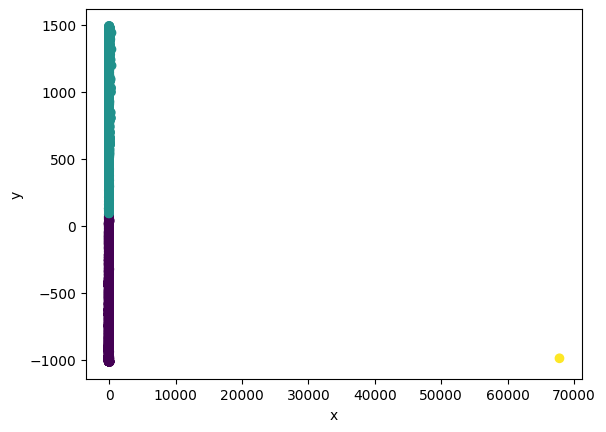

In [73]:
a.clusterization(3, table_writing=True)

## Создание карты для каждого маршрута

In [74]:
a.create_maps(r"C:\Users\demoexam\Cross_sections_modules\Number_1\Track_Map")

0    [C:\Users\demoexam\Cross_sections_modules\Numb...
1    [C:\Users\demoexam\Cross_sections_modules\Numb...
Name: map_paths, dtype: object

## Аугментация созданных карт, для увеличения выборки

In [75]:
a.augmentation_image()

## Сохранение в базу данных

In [76]:
a.db_save()

'Успешно!'

## Сохранение информационной таблицы

In [77]:
a.inf_table_read(r"C:\Users\demoexam\Cross_sections_modules\Number_1\info_table.csv")

'Таблица сохранена!'

In [78]:
a.inf_table

,Название,Перевод,Описание,Единицы измерения,Unnamed: 4
0,track_id,Номер маршрута,Порядковый номер точки,-,NaN
1,point_id,Номер точки,Порядковый номер машрута,-,NaN
2,time,Время,Время в которое была пройдена точка,-,NaN
3,latitude,Широта,Координата точки,-,NaN
4,longitude,Долгота,Координата точки,-,NaN
5,elevation,Высота,"Высота, на которой находится точка",Метры,NaN
6,steps,Шаги,Пройденной растояние в шагах от одной точки до...,-,NaN
7,cluster,Кластеры,Каждая точка разделена на кластеры по схожести,-,NaN
8,country,Страна,"Страна, в которой рассположена точка",-,NaN
9,place_type,Тип местности,"Тип местности, вокруг точки в радиусе 500 метров",-,NaN


## Визуальный и не визуальный анализ датасета

Графики


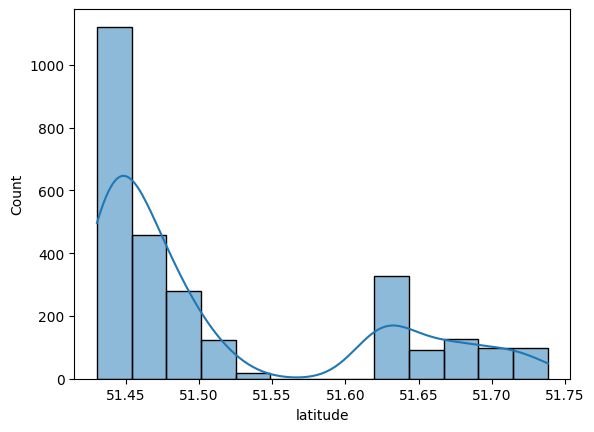

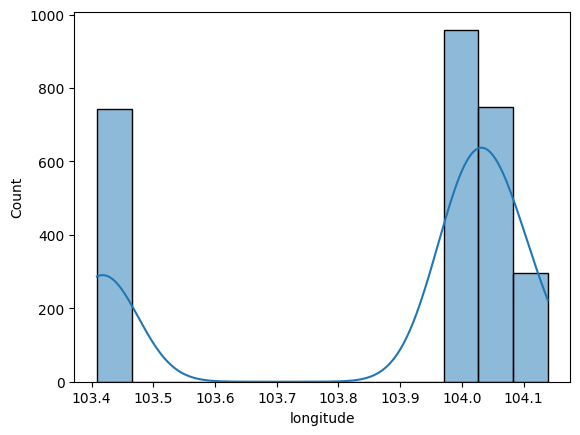

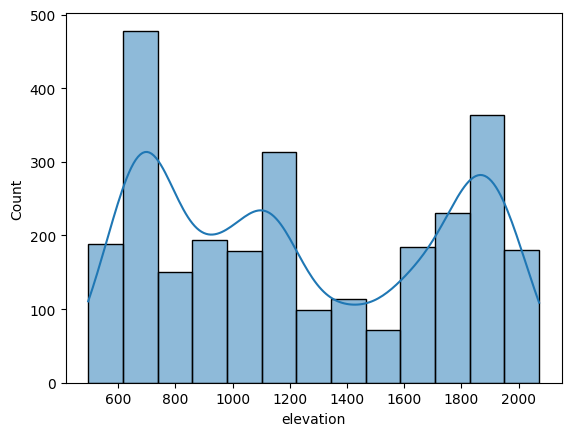

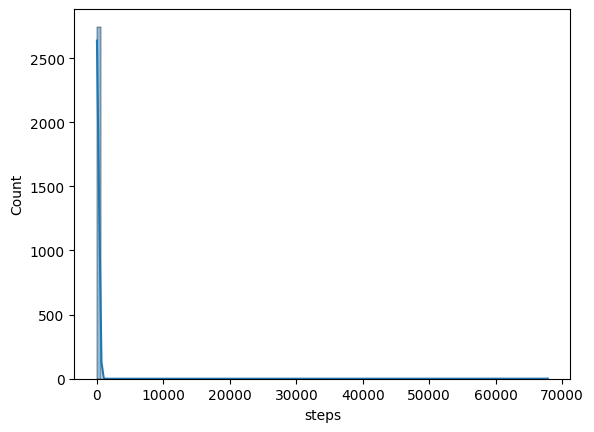

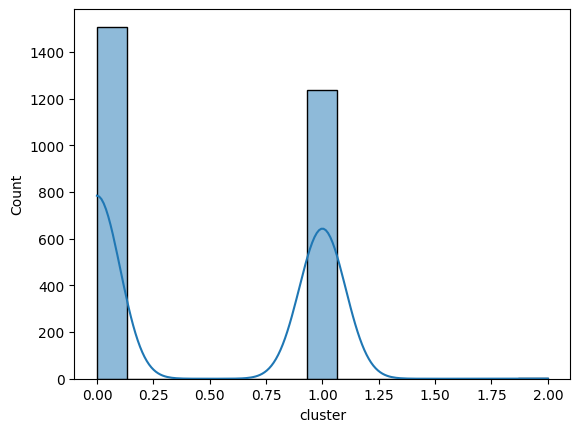

Тест Шапиро-Уилка: статистика=0.2898, p-значение=3.1812e-115
Данные не выглядят нормально (отвергаем нулевую гипотезу)


C:\Users\demoexam\AppData\Roaming\Python\Python313\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13730.
  res = hypotest_fun_out(*samples, **kwds)


In [79]:
a.graphic_distribution()

### Проведя визуальный и статистический анализ данных, можно сделать вывод, что данные не выглядят нормальными. В случае с широтой скошенность положительная. В случае с высотой и долготой двупиковый тип данных. По анализу кластеризации, можно сделать вывод, что 3 кластер преобладает над другими, по этому вероятно в будущем потребуется нормализировать данные, для лучшего результата при обучении моделей.